In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    confusion_matrix, f1_score, brier_score_loss,
)
import xgboost as xgb
import time
import warnings
warnings.filterwarnings('ignore')

DATA_DIR  = Path('../data/processed')
FIG_DIR   = Path('../outputs/figures')
TABLE_DIR = Path('../outputs/tables')

plt.rcParams.update({
    'figure.dpi'        : 150,
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

MODEL_COLORS = {
    'Logistic Regression' : '#1F77B4',
    'Random Forest'       : '#2CA02C',
    'XGBoost'             : '#D62728',
}

In [13]:
df22 = pd.read_csv(DATA_DIR / 'brfss_2022_clean.csv')
df23 = pd.read_csv(DATA_DIR / 'brfss_2023_clean.csv')

for df in [df22, df23]:
    df['CHECKUP1'] = df['CHECKUP1'].replace({8.0: 5.0})

OUTCOME = 'COPD'
WEIGHT  = '_LLCPWT'

print(f'Training (2022) : {len(df22):,} rows  |  '
      f'COPD: {df22[OUTCOME].sum():,} ({df22[OUTCOME].mean()*100:.2f}%)')
print(f'Validation (2023): {len(df23):,} rows  |  '
      f'COPD: {df23[OUTCOME].sum():,} ({df23[OUTCOME].mean()*100:.2f}%)')
print()
print('2023 data is being used for the first time in this notebook.')
print('It was not touched during training, CV, or any prior analysis.')

Training (2022) : 442,913 rows  |  COPD: 35,656 (8.05%)
Validation (2023): 431,257 rows  |  COPD: 33,097 (7.67%)

2023 data is being used for the first time in this notebook.
It was not touched during training, CV, or any prior analysis.


In [14]:
ORDINAL_FEATURES = [
    'INCOME3', 'EDUCA', 'SEXVAR', '_AGEG5YR', '_IMPRACE',
    'EMPLOY1', 'MARITAL', '_URBSTAT', '_SMOKER3', '_BMI5CAT',
    'PERSDOC3', 'CHECKUP1',
]
BINARY_FEATURES = [
    'EXERANY2', 'DRNKANY6', 'ASTHMA3', 'CVDINFR4', 'CVDCRHD4',
    'CVDSTRK3', 'HAVARTH3', 'CHCKDNY2', 'HLTHPLN2', 'MEDCOST1',
    'DIABETES', 'PREDIABETES',
]
ALL_FEATURES = ORDINAL_FEATURES + BINARY_FEATURES

# Surviving income interaction terms from notebook 06
INCOME_INT_COLS = [
    'INCOME3_x_EDUCA',
    'INCOME3_x_EXERANY2',
    'INCOME3_x__SMOKER3',
    'INCOME3_x_DIABETES',
    'INCOME3_x_CVDSTRK3',
    'INCOME3_x_DRNKANY6',
    'INCOME3_x_ASTHMA3',
    'INCOME3_x_MEDCOST1',
    'INCOME3_x__URBSTAT',
    'INCOME3_x_CVDCRHD4',
]
INT_FEATURES = ALL_FEATURES + INCOME_INT_COLS

def add_income_interactions(df):
    df = df.copy()
    for col in INCOME_INT_COLS:
        partner = col.replace('INCOME3_x_', '')
        df[col] = df['INCOME3'] * df[partner]
    return df

df22_int = add_income_interactions(df22)
df23_int = add_income_interactions(df23)

# Training and validation matrices
X_train      = df22[ALL_FEATURES]
y_train      = df22[OUTCOME]
X_train_int  = df22_int[INT_FEATURES]

X_val        = df23[ALL_FEATURES]
y_val        = df23[OUTCOME]
X_val_int    = df23_int[INT_FEATURES]

print(f'Training matrix   (baseline)    : {X_train.shape}')
print(f'Training matrix   (interaction) : {X_train_int.shape}')
print(f'Validation matrix (baseline)    : {X_val.shape}')
print(f'Validation matrix (interaction) : {X_val_int.shape}')

Training matrix   (baseline)    : (442913, 24)
Training matrix   (interaction) : (442913, 34)
Validation matrix (baseline)    : (431257, 24)
Validation matrix (interaction) : (431257, 34)


In [15]:
import joblib, time

MODEL_DIR = Path('../outputs/models')

n_neg = (y_train == 0).sum()
n_pos = y_train.sum()
scale_pos_weight = n_neg / n_pos

def make_tree_pre(ordinal_cols, binary_cols):
    return ColumnTransformer(transformers=[
        ('ord', SimpleImputer(strategy='median'),        ordinal_cols),
        ('bin', SimpleImputer(strategy='most_frequent'), binary_cols),
    ], remainder='drop')

def make_lr_pre(ordinal_cols, binary_cols):
    return ColumnTransformer(transformers=[
        ('ord', Pipeline([
            ('imp',   SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
        ]), ordinal_cols),
        ('bin', SimpleImputer(strategy='most_frequent'), binary_cols),
    ], remainder='drop')

INT_ORD = ORDINAL_FEATURES + INCOME_INT_COLS
INT_BIN = BINARY_FEATURES

# ── Load serialized baseline models from nb03 ─────────────────────────
print('Loading serialized baseline models from nb03...')
MODELS_BASE = {}
for name, fname in [
    ('Logistic Regression', 'logistic_regression_final.pkl'),
    ('Random Forest',       'random_forest_final.pkl'),
    ('XGBoost',             'xgboost_final.pkl'),
]:
    MODELS_BASE[name] = joblib.load(MODEL_DIR / fname)
    print(f'  Loaded: {fname}')

# ── Interaction models — retrained (not serialized in nb03) ──────────
def make_model_set(ord_cols, bin_cols):
    return {
        'Logistic Regression': Pipeline([
            ('pre', make_lr_pre(ord_cols, bin_cols)),
            ('clf', LogisticRegression(
                class_weight='balanced', max_iter=1000,
                solver='saga', random_state=42, n_jobs=-1,
            )),
        ]),
        'Random Forest': Pipeline([
            ('pre', make_tree_pre(ord_cols, bin_cols)),
            ('clf', RandomForestClassifier(
                n_estimators=200, class_weight='balanced',
                max_features='sqrt', min_samples_leaf=50,
                random_state=42, n_jobs=-1,
            )),
        ]),
        'XGBoost': Pipeline([
            ('pre', make_tree_pre(ord_cols, bin_cols)),
            ('clf', xgb.XGBClassifier(
                n_estimators=200, max_depth=6, learning_rate=0.1,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                tree_method='hist', eval_metric='auc',
                random_state=42, n_jobs=-1, verbosity=0,
            )),
        ]),
    }

MODELS_INT = make_model_set(INT_ORD, INT_BIN)
print(f'\nscale_pos_weight : {scale_pos_weight:.2f}')
print('Baseline models loaded. Interaction model set defined.')

Loading serialized baseline models from nb03...
  Loaded: logistic_regression_final.pkl
  Loaded: random_forest_final.pkl
  Loaded: xgboost_final.pkl

scale_pos_weight : 11.42
Baseline models loaded. Interaction model set defined.


In [16]:
# Baseline models already loaded from disk — no fitting needed.
# Only fit interaction-augmented models (not serialized in nb03).

print('Fitting interaction-augmented models on full BRFSS 2022...')
for name, pipe in MODELS_INT.items():
    t0 = time.time()
    pipe.fit(X_train_int, y_train)
    print(f'  {name}: {time.time()-t0:.1f}s')

print('\nAll models ready. Applying to held-out 2023.')

Fitting interaction-augmented models on full BRFSS 2022...
  Logistic Regression: 6.7s
  Random Forest: 31.3s
  XGBoost: 7.7s

All models ready. Applying to held-out 2023.


In [17]:
def youden_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    score = tpr - fpr
    return float(thresholds[np.argmax(score)])

def evaluate(y_true, y_prob, threshold):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    return {
        'auc' : roc_auc_score(y_true, y_prob),
        'ap' : average_precision_score(y_true, y_prob),
        'brier' : brier_score_loss(y_true, y_prob),
        'sensitivity' : sensitivity,
        'specificity' : specificity,
    }

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []
cv_thresh = {}

print('Running 5-fold CV on 2022 for threshold and AUC reference...')
for name, pipe in make_model_set(ORDINAL_FEATURES, BINARY_FEATURES).items():
    oof_prob = np.zeros(len(X_train), dtype=float)
    fold_aucs = []
    for train_idx, valid_idx in skf.split(X_train, y_train):
        pipe.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        fold_prob = pipe.predict_proba(X_train.iloc[valid_idx])[:, 1]
        oof_prob[valid_idx] = fold_prob
        fold_aucs.append(roc_auc_score(y_train.iloc[valid_idx], fold_prob))

    cv_auc = roc_auc_score(y_train, oof_prob)
    cv_rows.append({
        'Model' : name,
        'auc_mean' : cv_auc,
        'auc_std' : float(np.std(fold_aucs, ddof=1)) if len(fold_aucs) > 1 else 0.0,
    })
    cv_thresh[name] = youden_threshold(y_train, oof_prob)

cv_summary = pd.DataFrame(cv_rows).sort_values('Model').reset_index(drop=True)
PROBS_BASE = {name: pipe.predict_proba(X_val)[:, 1] for name, pipe in MODELS_BASE.items()}
PROBS_INT = {name: pipe.predict_proba(X_val_int)[:, 1] for name, pipe in MODELS_INT.items()}

print('CV summary:')
print(cv_summary.to_string(index=False))
print()
print('Derived CV thresholds:')
for name in cv_summary['Model']:
    print(f'  {name:<22} {cv_thresh[name]:.4f}')

print()
print('Validation probability caches ready: PROBS_BASE and PROBS_INT')

Running 5-fold CV on 2022 for threshold and AUC reference...
CV summary:
              Model  auc_mean  auc_std
Logistic Regression  0.847184 0.001642
      Random Forest  0.856041 0.002121
            XGBoost  0.857465 0.002006

Derived CV thresholds:
  Logistic Regression    0.4858
  Random Forest          0.4797
  XGBoost                0.4714

Validation probability caches ready: PROBS_BASE and PROBS_INT


In [18]:
# Use threshold derived from 2022 CV — not re-optimised on 2023.
# Re-optimising on 2023 would be data leakage.
# Report both: (a) 2022 CV threshold applied to 2023,
#              (b) Youden-optimal on 2023 for reference only.

results = []

for name in MODELS_BASE:
    thresh_cv  = cv_thresh.get(name, 0.5)
    thresh_23  = youden_threshold(y_val, PROBS_BASE[name])

    m_cv  = evaluate(y_val, PROBS_BASE[name], thresh_cv)
    m_23  = evaluate(y_val, PROBS_BASE[name], thresh_23)
    m_int = evaluate(y_val, PROBS_INT[name],  thresh_cv)

    # Load 2022 CV AUC for delta
    cv_auc = cv_summary.loc[
        cv_summary['Model'] == name, 'auc_mean'].values[0]

    results.append({
        'Model'           : name,
        'CV AUC (2022)'   : cv_auc,
        'Val AUC (2023)'  : m_cv['auc'],
        'ΔAUC'            : m_cv['auc'] - cv_auc,
        'Val Sens (CV thresh)' : m_cv['sensitivity'],
        'Val Spec (CV thresh)' : m_cv['specificity'],
        'Val Sens (2023 thresh)': m_23['sensitivity'],
        'Val Spec (2023 thresh)': m_23['specificity'],
        'Val AUC Int'     : m_int['auc'],
        'ΔAUC Int'        : m_int['auc'] - cv_auc,
        'Val AP'          : m_cv['ap'],
        'Val Brier'       : m_cv['brier'],
        'CV threshold'    : thresh_cv,
        '2023 threshold'  : thresh_23,
    })

results_df = pd.DataFrame(results)

print('=== TEMPORAL VALIDATION RESULTS ===\n')
print(f'{"Model":<22}  {"CV AUC":>8}  {"Val AUC":>8}  '
      f'{"ΔAUC":>8}  {"Val Sens":>9}  {"Val Spec":>9}')
print('-' * 72)

for _, r in results_df.iterrows():
    flag = ('✓' if abs(r['ΔAUC']) <= 0.03
            else '~' if abs(r['ΔAUC']) <= 0.05
            else '⚠')
    print(f'{r["Model"]:<22}  {r["CV AUC (2022)"]:>8.4f}  '
          f'{r["Val AUC (2023)"]:>8.4f}  '
          f'{r["ΔAUC"]:>+8.4f}  '
          f'{r["Val Sens (CV thresh)"]:>9.3f}  '
          f'{r["Val Spec (CV thresh)"]:>9.3f}  {flag}')

print()
print('Interaction-augmented models:')
print(f'{"Model":<22}  {"CV AUC":>8}  {"Val AUC":>8}  {"ΔAUC":>8}')
print('-' * 50)
for _, r in results_df.iterrows():
    print(f'{r["Model"]:<22}  {r["CV AUC (2022)"]:>8.4f}  '
          f'{r["Val AUC Int"]:>8.4f}  {r["ΔAUC Int"]:>+8.4f}')

=== TEMPORAL VALIDATION RESULTS ===

Model                     CV AUC   Val AUC      ΔAUC   Val Sens   Val Spec
------------------------------------------------------------------------
Logistic Regression       0.8472    0.8479   +0.0007      0.780      0.760  ✓
Random Forest             0.8560    0.8572   +0.0012      0.795      0.764  ✓
XGBoost                   0.8575    0.8584   +0.0009      0.796      0.765  ✓

Interaction-augmented models:
Model                     CV AUC   Val AUC      ΔAUC
--------------------------------------------------
Logistic Regression       0.8472    0.8481   +0.0009
Random Forest             0.8560    0.8566   +0.0005
XGBoost                   0.8575    0.8584   +0.0009


In [19]:
print('=== THRESHOLD STABILITY CHECK ===\n')
print('2022 CV threshold vs 2023 Youden-optimal threshold.')
print('Large divergence = model is not well-calibrated across years.\n')

print(f'{"Model":<22}  {"CV thresh (2022)":>18}  '
      f'{"Youden thresh (2023)":>22}  {"Δ":>6}')
print('-' * 72)

for _, r in results_df.iterrows():
    delta = r['2023 threshold'] - r['CV threshold']
    print(f'{r["Model"]:<22}  {r["CV threshold"]:>18.4f}  '
          f'{r["2023 threshold"]:>22.4f}  {delta:>+6.4f}')

print()
print('At 2023 Youden-optimal threshold:')
print(f'{"Model":<22}  {"Sens":>8}  {"Spec":>8}')
print('-' * 42)
for _, r in results_df.iterrows():
    print(f'{r["Model"]:<22}  '
          f'{r["Val Sens (2023 thresh)"]:>8.3f}  '
          f'{r["Val Spec (2023 thresh)"]:>8.3f}')

=== THRESHOLD STABILITY CHECK ===

2022 CV threshold vs 2023 Youden-optimal threshold.
Large divergence = model is not well-calibrated across years.

Model                     CV thresh (2022)    Youden thresh (2023)       Δ
------------------------------------------------------------------------
Logistic Regression                 0.4858                  0.4946  +0.0088
Random Forest                       0.4797                  0.4845  +0.0047
XGBoost                             0.4714                  0.5062  +0.0348

At 2023 Youden-optimal threshold:
Model                       Sens      Spec
------------------------------------------
Logistic Regression        0.772     0.768
Random Forest              0.792     0.768
XGBoost                    0.774     0.789


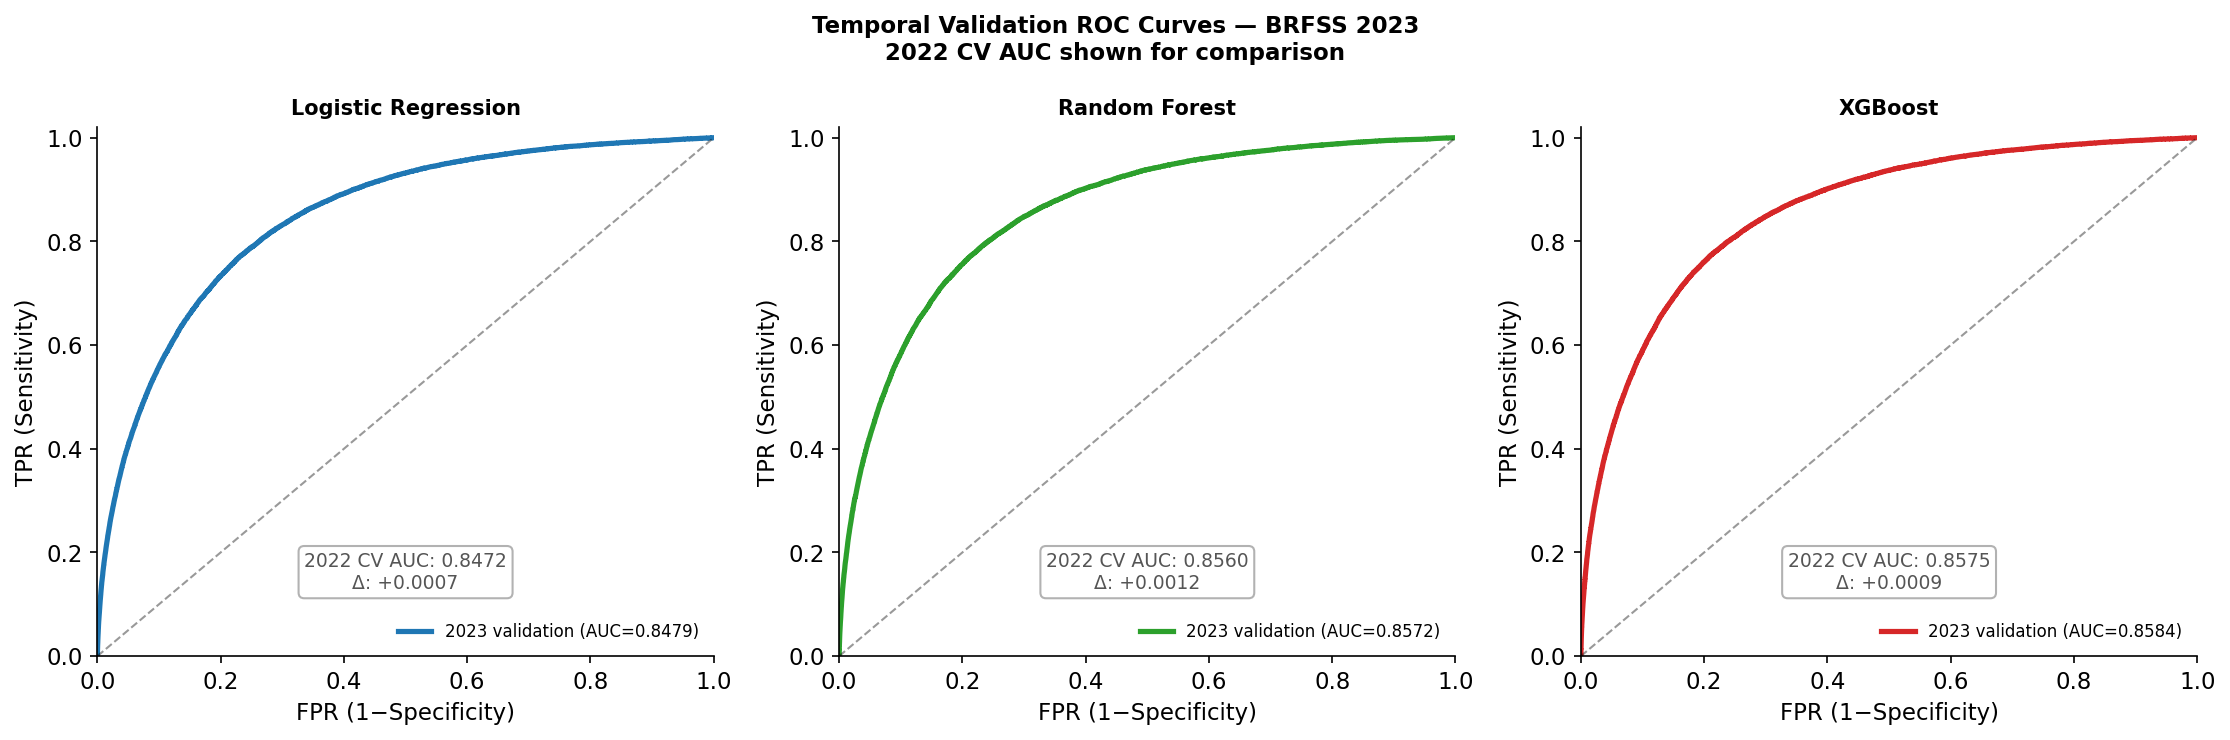

Saved fig21_temporal_validation_roc.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, name in zip(axes, MODELS_BASE.keys()):
    color = MODEL_COLORS[name]

    # 2023 validation ROC
    fpr_val, tpr_val, _ = roc_curve(y_val, PROBS_BASE[name])
    auc_val = roc_auc_score(y_val, PROBS_BASE[name])

    # 2022 CV AUC (no curve stored — show as annotation)
    auc_cv = cv_summary.loc[
        cv_summary['Model'] == name, 'auc_mean'].values[0]
    delta = auc_val - auc_cv

    ax.plot(fpr_val, tpr_val, lw=2.5, color=color,
            label=f'2023 validation (AUC={auc_val:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)

    ax.text(0.5, 0.12,
            f'2022 CV AUC: {auc_cv:.4f}\nΔ: {delta:+.4f}',
            transform=ax.transAxes, ha='center', va='bottom',
            fontsize=9, color='#555',
            bbox=dict(boxstyle='round,pad=0.3', fc='white',
                      ec='#aaa', alpha=0.9))

    thresh_cv = cv_thresh.get(name, 0.5)
    # Mark operating point at CV threshold
    dists = np.abs(
        np.array([0]) - fpr_val +
        np.abs(1 - tpr_val))
    # Find point on ROC closest to CV threshold operating point
    y_prob_sorted = np.sort(PROBS_BASE[name])[::-1]
    op_idx = np.searchsorted(-y_prob_sorted, -thresh_cv)
    if op_idx < len(fpr_val):
        ax.scatter(fpr_val[op_idx], tpr_val[op_idx],
                   color=color, s=60, zorder=5,
                   label=f'CV threshold ({thresh_cv:.3f})')

    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('FPR (1−Specificity)')
    ax.set_ylabel('TPR (Sensitivity)')
    ax.legend(frameon=False, fontsize=8, loc='lower right')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)

plt.suptitle('Temporal Validation ROC Curves — BRFSS 2023\n'
             '2022 CV AUC shown for comparison',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig21_temporal_validation_roc.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig21_temporal_validation_roc.png')

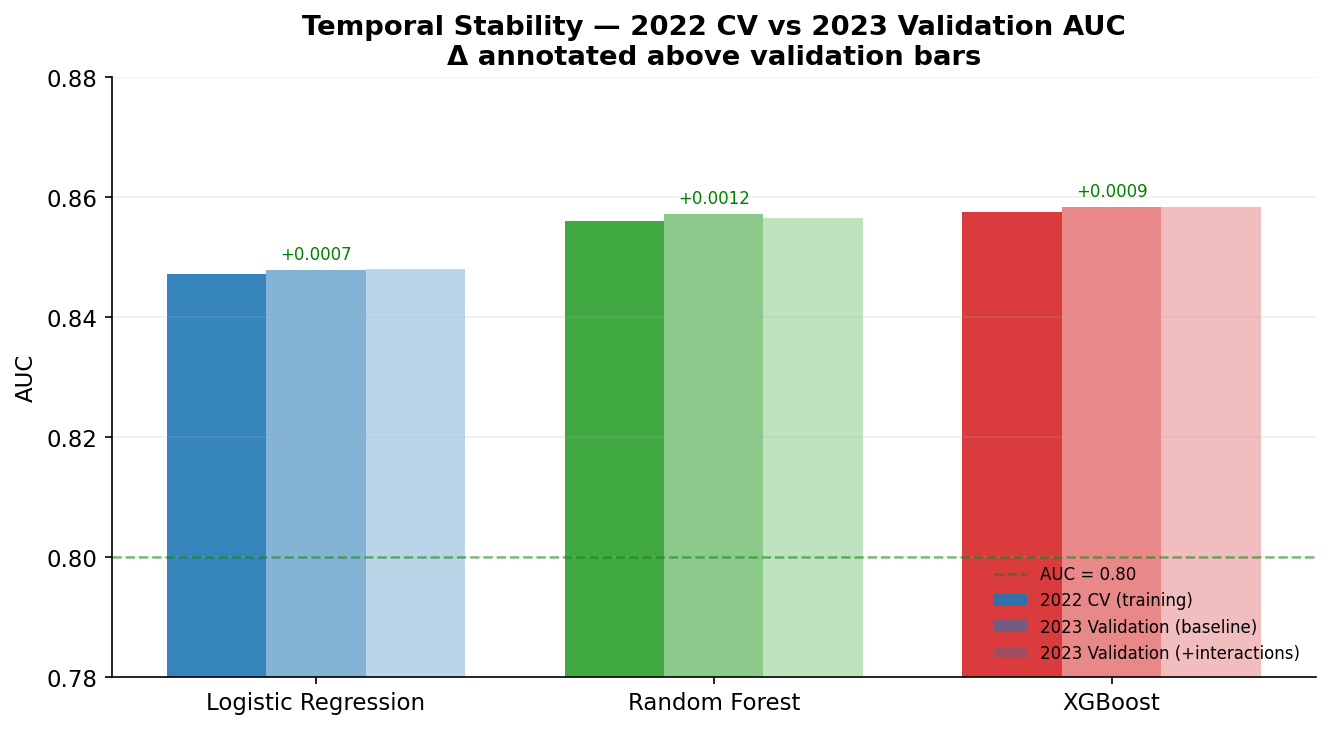

Saved fig22_temporal_auc_stability.png


In [21]:
models    = list(MODELS_BASE.keys())
cv_aucs   = [cv_summary.loc[cv_summary['Model']==n,
                              'auc_mean'].values[0] for n in models]
val_aucs  = [roc_auc_score(y_val, PROBS_BASE[n]) for n in models]
val_aucs_int = [roc_auc_score(y_val, PROBS_INT[n]) for n in models]

x = np.arange(len(models))
w = 0.25

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - w,   cv_aucs,      w, label='2022 CV (training)',
               color=[MODEL_COLORS[n] for n in models], alpha=0.9)
bars2 = ax.bar(x,       val_aucs,     w, label='2023 Validation (baseline)',
               color=[MODEL_COLORS[n] for n in models], alpha=0.55)
bars3 = ax.bar(x + w,   val_aucs_int, w, label='2023 Validation (+interactions)',
               color=[MODEL_COLORS[n] for n in models], alpha=0.3)

# Annotate deltas
for i, (cv, vl) in enumerate(zip(cv_aucs, val_aucs)):
    delta = vl - cv
    ax.annotate(f'{delta:+.4f}',
                xy=(i, vl), xytext=(0, 5),
                textcoords='offset points',
                ha='center', fontsize=8,
                color='green' if delta > -0.03 else '#D62728')

ax.axhline(0.80, color='green', ls='--', lw=1.2, alpha=0.5,
           label='AUC = 0.80')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('AUC')
ax.set_ylim(0.78, 0.88)
ax.set_title('Temporal Stability — 2022 CV vs 2023 Validation AUC\n'
             'Δ annotated above validation bars',
             fontweight='bold')
ax.legend(frameon=False, fontsize=8, loc='lower right')
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig22_temporal_auc_stability.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig22_temporal_auc_stability.png')

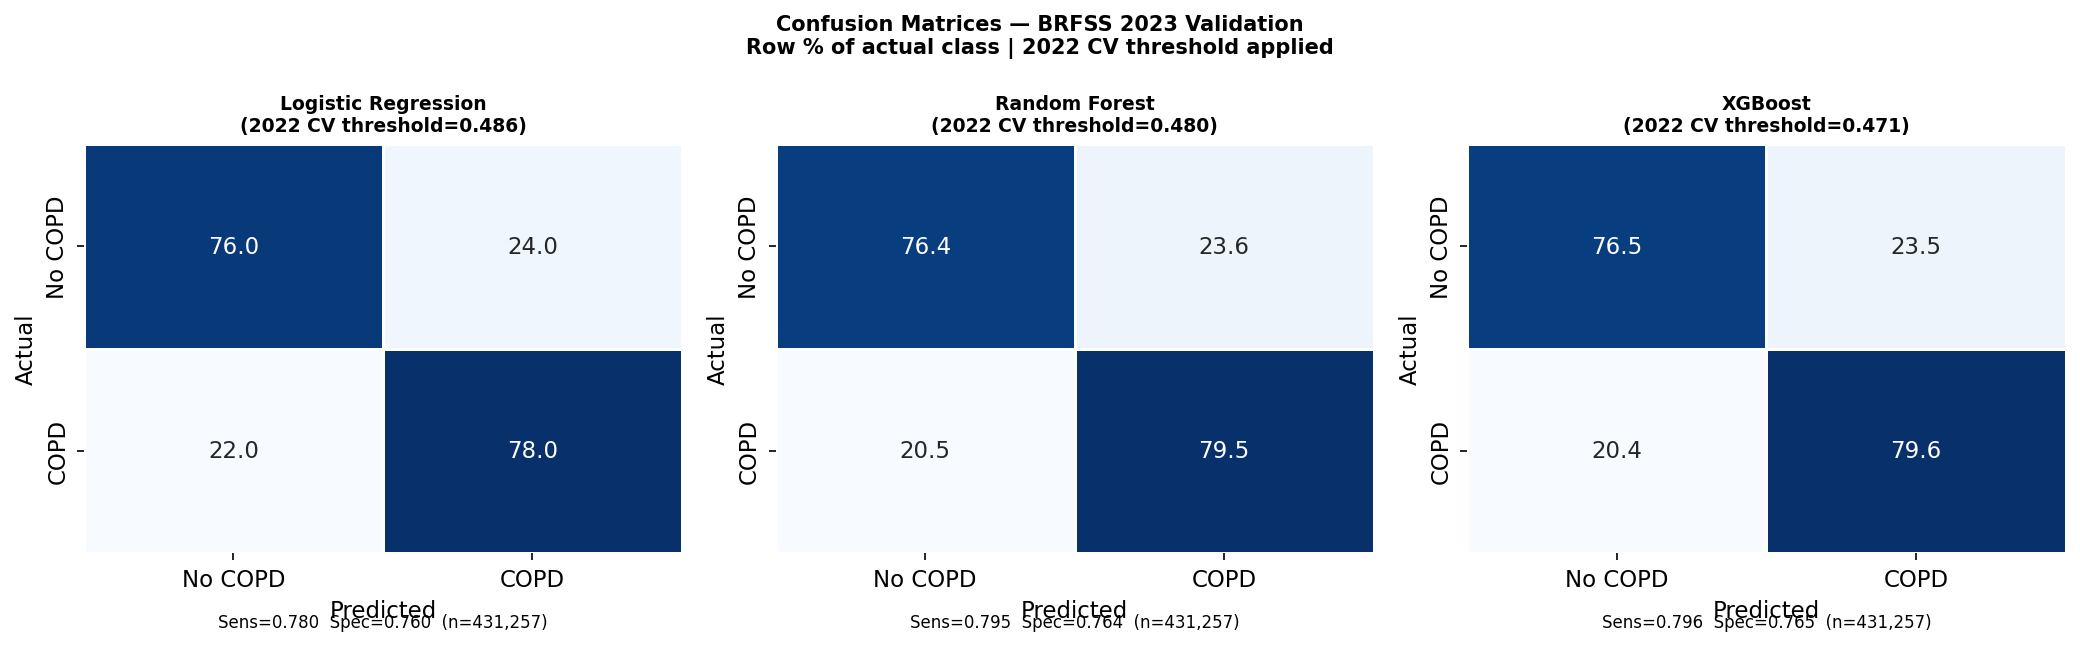

Saved fig23_validation_confusion_matrices.png


In [22]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, name in zip(axes, MODELS_BASE.keys()):
    thresh = cv_thresh.get(name, 0.5)
    y_pred = (PROBS_BASE[name] >= thresh).astype(int)
    cm     = confusion_matrix(y_val, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax,
                xticklabels=['No COPD', 'COPD'],
                yticklabels=['No COPD', 'COPD'],
                cbar=False, linewidths=0.5)

    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)

    ax.set_title(f'{name}\n(2022 CV threshold={thresh:.3f})',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.text(0.5, -0.18,
            f'Sens={sens:.3f}  Spec={spec:.3f}  '
            f'(n={len(y_val):,})',
            transform=ax.transAxes, ha='center', fontsize=8)

plt.suptitle('Confusion Matrices — BRFSS 2023 Validation\n'
             'Row % of actual class | 2022 CV threshold applied',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig23_validation_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig23_validation_confusion_matrices.png')

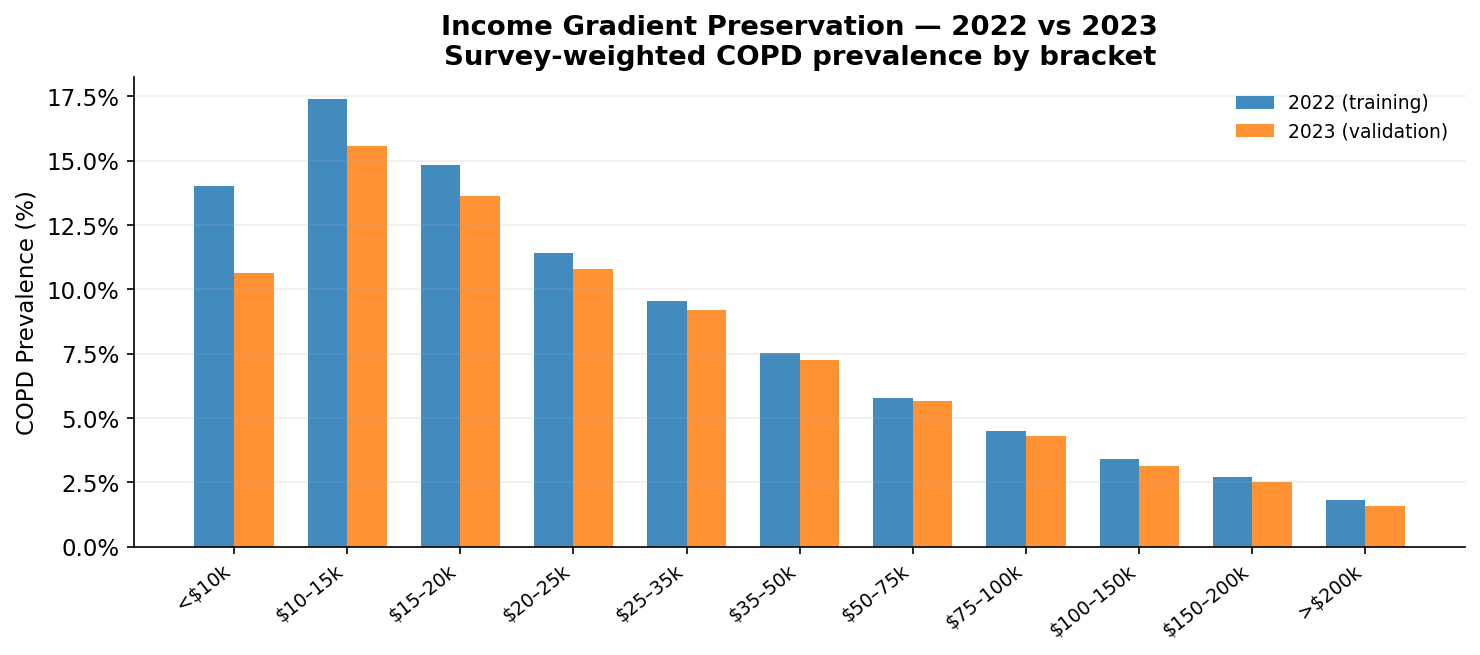

2022 Spearman ρ: -0.973
2023 Spearman ρ: -0.945
Gradient preserved: ✓
Saved fig24_gradient_preservation.png


In [23]:
# Confirm the income gradient in COPD prevalence is preserved in 2023.
# If the gradient shifts dramatically year-to-year, the 2022-trained
# model's income interaction terms may not generalise.

INCOME_LABELS = {
    1: '<$10k',    2: '$10–15k',  3: '$15–20k',  4: '$20–25k',
    5: '$25–35k',  6: '$35–50k',  7: '$50–75k',  8: '$75–100k',
    9: '$100–150k',10: '$150–200k',11: '>$200k',
}

def income_gradient(df):
    rows = []
    for val in sorted(df['INCOME3'].dropna().unique()):
        sub = df[df['INCOME3'] == val]
        w   = sub[WEIGHT].fillna(0)
        y   = sub[OUTCOME].astype(float)
        p   = np.average(y, weights=w)
        rows.append({
            'income_val'  : int(val),
            'income_label': INCOME_LABELS.get(int(val), str(int(val))),
            'prevalence'  : p * 100,
        })
    return pd.DataFrame(rows)

grad22 = income_gradient(df22)
grad23 = income_gradient(df23)

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(grad22))
w = 0.35

ax.bar(x - w/2, grad22['prevalence'], w,
       color='#1F77B4', alpha=0.85, label='2022 (training)')
ax.bar(x + w/2, grad23['prevalence'], w,
       color='#FF7F0E', alpha=0.85, label='2023 (validation)')

ax.set_xticks(x)
ax.set_xticklabels(grad22['income_label'], rotation=38,
                   ha='right', fontsize=9)
ax.set_ylabel('COPD Prevalence (%)')
ax.set_title('Income Gradient Preservation — 2022 vs 2023\n'
             'Survey-weighted COPD prevalence by bracket',
             fontweight='bold')
ax.legend(frameon=False, fontsize=9)
ax.grid(axis='y', alpha=0.2)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig24_gradient_preservation.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Spearman correlation check
from scipy.stats import spearmanr
rho22, _ = spearmanr(grad22['income_val'], grad22['prevalence'])
rho23, _ = spearmanr(grad23['income_val'], grad23['prevalence'])
print(f'2022 Spearman ρ: {rho22:.3f}')
print(f'2023 Spearman ρ: {rho23:.3f}')
print(f'Gradient preserved: {"✓" if abs(rho22-rho23) < 0.05 else "⚠ Check"}')
print('Saved fig24_gradient_preservation.png')

In [24]:
# Asthma-COPD Overlap Syndrome (ACOS) sensitivity analysis.
# ASTHMA3 is the top predictor in multiple models — model may be
# partially predicting asthma rather than COPD.
# Refit XGBoost without ASTHMA3, validate on 2023, compare AUC.

FEATURES_NO_ASTHMA = [f for f in ALL_FEATURES if f != 'ASTHMA3']

pipe_no_asthma = Pipeline([
    ('pre', make_tree_pre(
        [f for f in ORDINAL_FEATURES if f != 'ASTHMA3'],
        [f for f in BINARY_FEATURES  if f != 'ASTHMA3'],
    )),
    ('clf', xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        tree_method='hist', eval_metric='auc',
        random_state=42, n_jobs=-1, verbosity=0,
    )),
])

print('Fitting ACOS sensitivity model (XGBoost, no ASTHMA3)...')
t0 = time.time()
pipe_no_asthma.fit(
    df22[FEATURES_NO_ASTHMA], y_train)
print(f'  Fitted in {time.time()-t0:.1f}s')

y_prob_no_asthma = pipe_no_asthma.predict_proba(
    df23[FEATURES_NO_ASTHMA])[:, 1]
auc_no_asthma    = roc_auc_score(y_val, y_prob_no_asthma)
auc_full_xgb     = roc_auc_score(y_val, PROBS_BASE['XGBoost'])

print()
print('=== ACOS SENSITIVITY ANALYSIS ===\n')
print(f'XGBoost full model (with ASTHMA3) : AUC = {auc_full_xgb:.4f}')
print(f'XGBoost excl. ASTHMA3             : AUC = {auc_no_asthma:.4f}')
print(f'ΔAUC from removing asthma         : {auc_no_asthma-auc_full_xgb:+.4f}')
print()
if abs(auc_full_xgb - auc_no_asthma) < 0.01:
    print('✓ AUC drop < 0.01 — model performance is not driven by asthma.')
    print('  ACOS confounding is unlikely. Asthma is a genuine predictor.')
elif abs(auc_full_xgb - auc_no_asthma) < 0.03:
    print('~ AUC drop 0.01–0.03 — moderate asthma contribution.')
    print('  Note ACOS as a limitation. Report both models in supplement.')
else:
    print('⚠ AUC drop > 0.03 — asthma is load-bearing for model performance.')
    print('  Strong ACOS concern. Discuss explicitly in limitations.')
    print('  Consider making asthma-excluded model the primary result.')

# ── ACOS calibration impact ───────────────────────────────────────────
# Does removing asthma improve or worsen calibration?
# Brier score (lower = better) captures both discrimination + calibration.

brier_full      = brier_score_loss(y_val, PROBS_BASE['XGBoost'])
brier_no_asthma = brier_score_loss(y_val, y_prob_no_asthma)

print(f'\nBrier score comparison:')
print(f'  Full model (with ASTHMA3)  : {brier_full:.4f}')
print(f'  Excl. ASTHMA3              : {brier_no_asthma:.4f}')
print(f'  Δ Brier                    : {brier_no_asthma - brier_full:+.4f}')

if brier_no_asthma > brier_full:
    print('  → Removing asthma worsens both discrimination and calibration.')
    print('  → Asthma is a genuine predictor, not just an ACOS artifact.')
else:
    print('  → Removing asthma improves calibration despite AUC loss.')
    print('  → Asthma may be introducing calibration bias via ACOS overlap.')

# Report both AUC and Brier for the asthma-excluded model
print(f'\nACOS sensitivity table for paper:')
print(f'  {"Metric":<20} {"Full model":>12} {"Excl. asthma":>14} {"Delta":>8}')
print(f'  {"-"*56}')
print(f'  {"AUC":<20} {auc_full_xgb:>12.4f} {auc_no_asthma:>14.4f} '
      f'{auc_no_asthma - auc_full_xgb:>+8.4f}')
print(f'  {"Brier":<20} {brier_full:>12.4f} {brier_no_asthma:>14.4f} '
      f'{brier_no_asthma - brier_full:>+8.4f}')

Fitting ACOS sensitivity model (XGBoost, no ASTHMA3)...
  Fitted in 2.7s

=== ACOS SENSITIVITY ANALYSIS ===

XGBoost full model (with ASTHMA3) : AUC = 0.8584
XGBoost excl. ASTHMA3             : AUC = 0.8337
ΔAUC from removing asthma         : -0.0246

~ AUC drop 0.01–0.03 — moderate asthma contribution.
  Note ACOS as a limitation. Report both models in supplement.

Brier score comparison:
  Full model (with ASTHMA3)  : 0.1477
  Excl. ASTHMA3              : 0.1607
  Δ Brier                    : +0.0130
  → Removing asthma worsens both discrimination and calibration.
  → Asthma is a genuine predictor, not just an ACOS artifact.

ACOS sensitivity table for paper:
  Metric                 Full model   Excl. asthma    Delta
  --------------------------------------------------------
  AUC                        0.8584         0.8337  -0.0246
  Brier                      0.1477         0.1607  +0.0130


In [ ]:
# ── Final results table ───────────────────────────────────────────────
val_rows = []
for name in MODELS_BASE:
    cv_auc   = cv_summary.loc[
        cv_summary['Model'] == name, 'auc_mean'].values[0]
    thresh   = cv_thresh.get(name, 0.5)
    m_base   = evaluate(y_val, PROBS_BASE[name], thresh)
    m_int    = evaluate(y_val, PROBS_INT[name],  thresh)

    val_rows.append({
        'Model'              : name,
        'CV_AUC_2022'        : cv_auc,
        'Val_AUC_2023'       : m_base['auc'],
        'Delta_AUC'          : m_base['auc'] - cv_auc,
        'Val_Sensitivity'    : m_base['sensitivity'],
        'Val_Specificity'    : m_base['specificity'],
        'Val_AP'             : m_base['ap'],
        'Val_Brier'          : m_base['brier'],
        'Val_AUC_Int'        : m_int['auc'],
        'Delta_AUC_Int'      : m_int['auc'] - cv_auc,
        'Val_Sens_Int'       : m_int['sensitivity'],
        'Val_Spec_Int'       : m_int['specificity'],
        'CV_threshold'       : thresh,
        'ACOS_AUC_no_asthma' : auc_no_asthma if name == 'XGBoost' else np.nan,
    })

val_df = pd.DataFrame(val_rows)
val_df.to_csv(TABLE_DIR / 'validation_results.csv', index=False)

print('=== NOTEBOOK 07 SUMMARY — TEMPORAL VALIDATION ===\n')
print(f'{"Model":<22}  {"CV AUC":>8}  {"Val AUC":>9}  '
      f'{"ΔAUC":>8}  {"Stability":>10}')
print('-' * 65)
for _, r in val_df.iterrows():
    d = r['Delta_AUC']
    stability = ('✓ Stable' if abs(d) <= 0.03
                 else '~ Acceptable' if abs(d) <= 0.05
                 else '⚠ Unstable')
    print(f'{r["Model"]:<22}  {r["CV_AUC_2022"]:>8.4f}  '
          f'{r["Val_AUC_2023"]:>9.4f}  {d:>+8.4f}  {stability:>10}')

print()
print(f'Benchmark (diabetes paper): 0.829 → 0.806  (Δ=−0.023)')
print()
print('ACOS sensitivity (XGBoost):')
print(f'  Full model AUC  : {auc_full_xgb:.4f}')
print(f'  Excl. asthma    : {auc_no_asthma:.4f}')
print(f'  Δ               : {auc_no_asthma-auc_full_xgb:+.4f}')
print()
print('Saved:')
print('  validation_results.csv')

=== NOTEBOOK 07 SUMMARY — TEMPORAL VALIDATION ===

Model                     CV AUC    Val AUC      ΔAUC   Stability
-----------------------------------------------------------------
Logistic Regression       0.8472     0.8479   +0.0007    ✓ Stable
Random Forest             0.8560     0.8572   +0.0012    ✓ Stable
XGBoost                   0.8575     0.8584   +0.0009    ✓ Stable

Benchmark (diabetes paper): 0.829 → 0.806  (Δ=−0.023)

ACOS sensitivity (XGBoost):
  Full model AUC  : 0.8584
  Excl. asthma    : 0.8337
  Δ               : -0.0246

Saved:
  validation_results.csv

Pipeline complete. All 7 notebooks finished.
Next step: manuscript writing.


Evaluating 2022-fitted calibration on 2023 held-out sample...
  Loaded: logistic_regression_isotonic_calibrator.pkl
  Loaded: random_forest_isotonic_calibrator.pkl
  Loaded: xgboost_isotonic_calibrator.pkl

Generating 2023 predictions...

=== CALIBRATION ON 2023 — BRACKET-LEVEL BRIER SCORE ===

Model                  Bracket                 Uncal Brier    Cal Brier       n
------------------------------------------------------------------------------
Logistic Regression    Low (<$25k)                  0.2786       0.1087  49,915
Logistic Regression    Mid-low ($25–50k)            0.2089       0.0754  85,617
Logistic Regression    Mid-high ($50–150k)          0.1246       0.0424 158,917
Logistic Regression    High (>$150k)                0.0561       0.0198  51,061
Random Forest          Low (<$25k)                  0.2423       0.1052  49,915
Random Forest          Mid-low ($25–50k)            0.1948       0.0743  85,617
Random Forest          Mid-high ($50–150k)          0.1175       

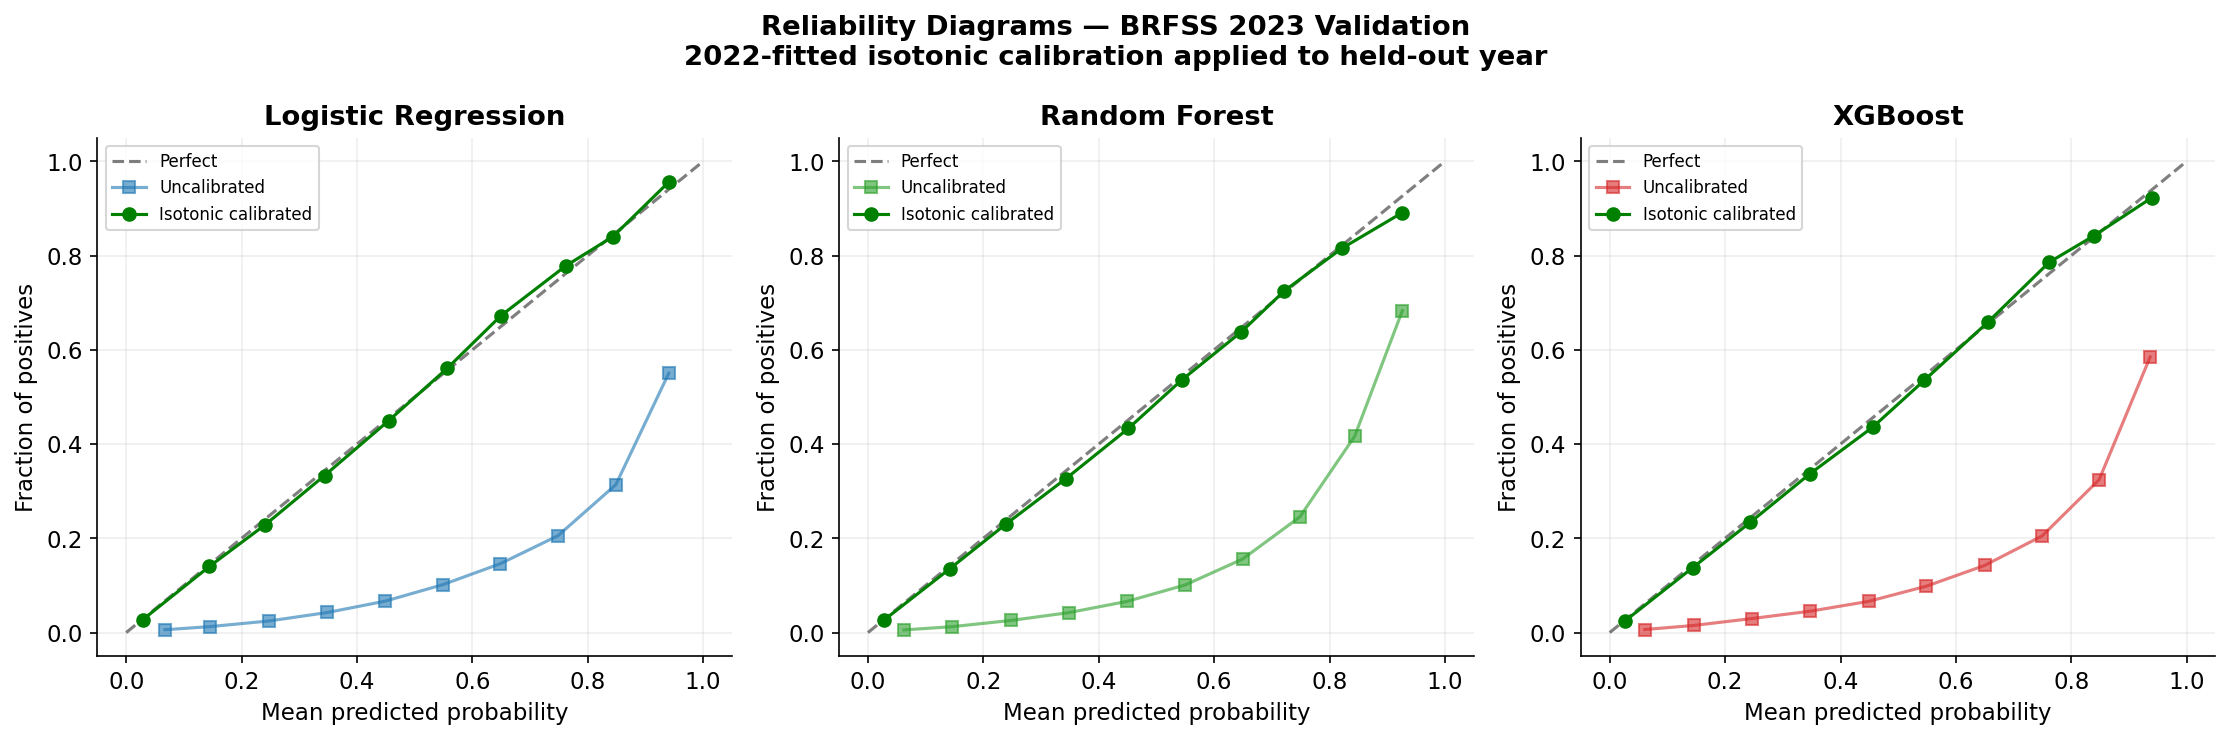


Saved calibration_2023_validation.csv and fig25_calibration_2023.png


In [26]:
# ── Calibration evaluation on held-out 2023 sample ───────────────────
import joblib
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

print('Evaluating 2022-fitted calibration on 2023 held-out sample...')

# Load 2022-fitted isotonic calibrators
CALIB_MODELS = {}
for name, fname in [
    ('Logistic Regression', 'logistic_regression_isotonic_calibrator.pkl'),
    ('Random Forest',       'random_forest_isotonic_calibrator.pkl'),
    ('XGBoost',             'xgboost_isotonic_calibrator.pkl'),
]:
    CALIB_MODELS[name] = joblib.load(MODEL_DIR / fname)
    print(f'  Loaded: {fname}')

# Get 2023 raw predictions from loaded baseline models
print('\nGenerating 2023 predictions...')
val_probs_raw  = {}
val_probs_cal  = {}

for name, pipe in MODELS_BASE.items():
    raw = pipe.predict_proba(X_val)[:, 1]
    cal = CALIB_MODELS[name].predict(raw)
    val_probs_raw[name] = raw
    val_probs_cal[name] = cal

# Bracket-level calibration error on 2023
INCOME_BANDS = {
    'Low (<$25k)'     : [1,2,3,4],
    'Mid-low ($25–50k)': [5,6],
    'Mid-high ($50–150k)': [7,8,9],
    'High (>$150k)'   : [10,11],
}

print('\n=== CALIBRATION ON 2023 — BRACKET-LEVEL BRIER SCORE ===\n')
print(f'{"Model":<22} {"Bracket":<22} {"Uncal Brier":>12} {"Cal Brier":>12} {"n":>7}')
print('-' * 78)

calib_results = []
for name in MODELS_BASE:
    for band_label, codes in INCOME_BANDS.items():
        mask = X_val['INCOME3'].isin(codes)
        if mask.sum() < 10:
            continue
        y_b   = y_val[mask].values
        raw_b = val_probs_raw[name][mask]
        cal_b = val_probs_cal[name][mask]
        bs_raw = brier_score_loss(y_b, raw_b)
        bs_cal = brier_score_loss(y_b, cal_b)
        print(f'{name:<22} {band_label:<22} {bs_raw:>12.4f} {bs_cal:>12.4f} {mask.sum():>7,}')
        calib_results.append({
            'model': name, 'band': band_label,
            'brier_uncalibrated': bs_raw,
            'brier_calibrated': bs_cal,
            'n': mask.sum()
        })

pd.DataFrame(calib_results).to_csv(
    TABLE_DIR / 'calibration_2023_validation.csv', index=False)

# Reliability diagrams on 2023
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
model_names = list(MODELS_BASE.keys())
colors = ['#1F77B4', '#2CA02C', '#D62728']

for ax, name, color in zip(axes, model_names, colors):
    frac_pos_raw, mean_pred_raw = calibration_curve(
        y_val, val_probs_raw[name], n_bins=10)
    frac_pos_cal, mean_pred_cal = calibration_curve(
        y_val, val_probs_cal[name], n_bins=10)
    ax.plot([0,1],[0,1], 'k--', label='Perfect', alpha=0.5)
    ax.plot(mean_pred_raw, frac_pos_raw, 's-',
            color=color, alpha=0.6, label='Uncalibrated')
    ax.plot(mean_pred_cal, frac_pos_cal, 'o-',
            color='green', label='Isotonic calibrated')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

fig.suptitle('Reliability Diagrams — BRFSS 2023 Validation\n'
             '2022-fitted isotonic calibration applied to held-out year',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig25_calibration_2023.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved calibration_2023_validation.csv and fig25_calibration_2023.png')